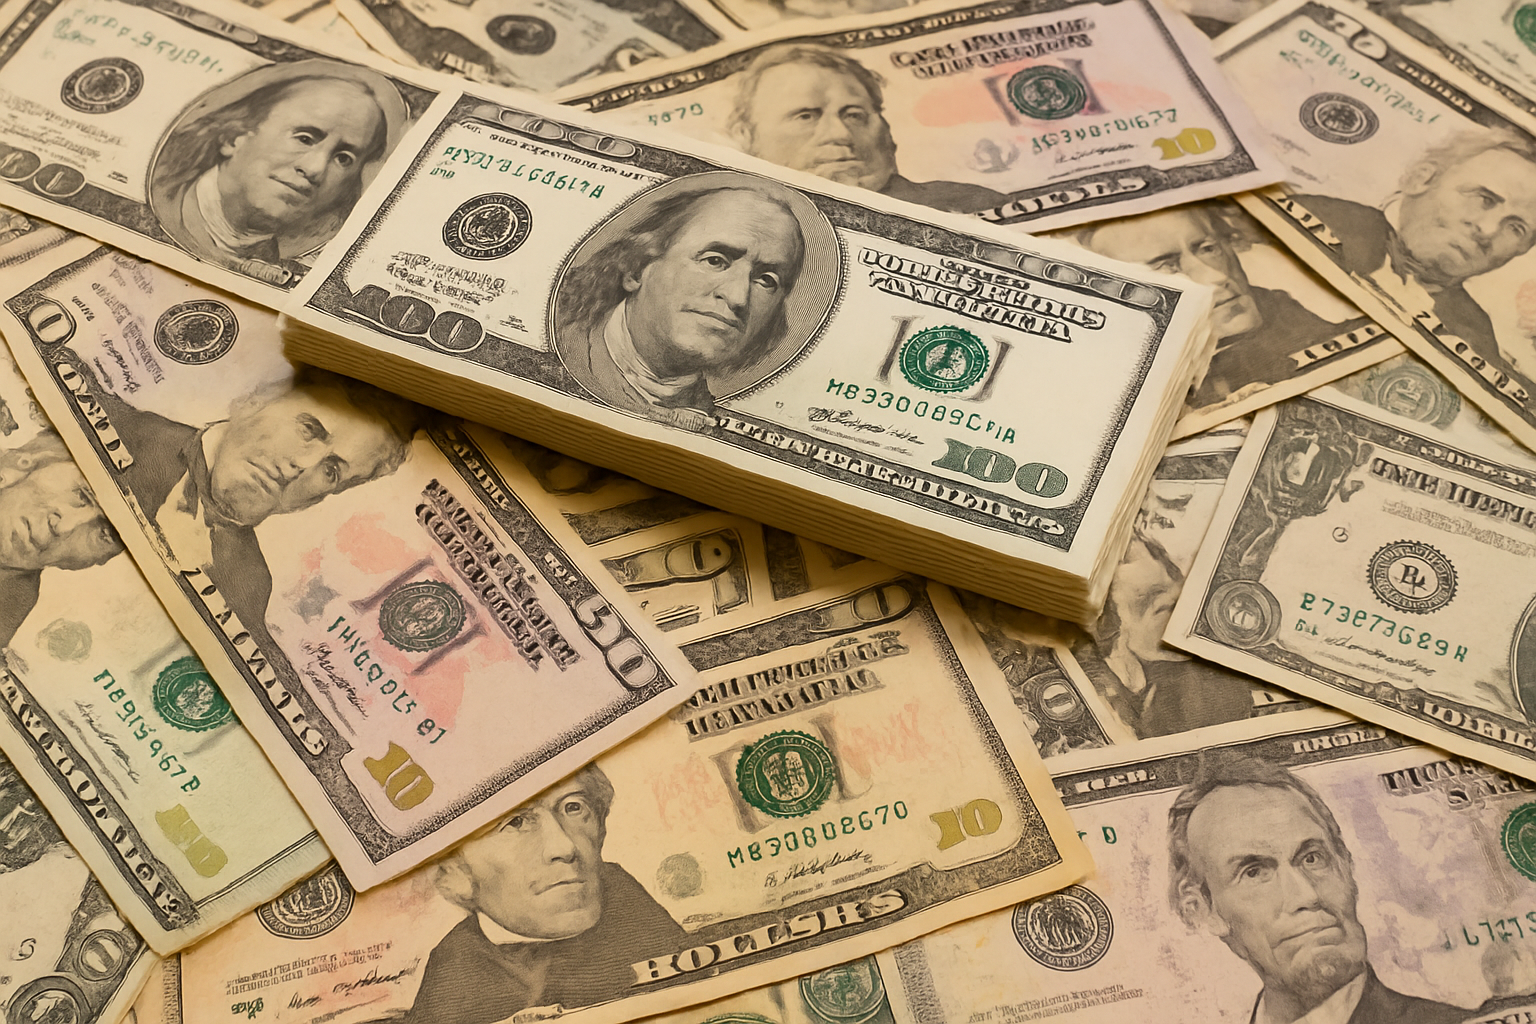

#**Income Level Prediction**

##-Introduction
####-Project Goal
Develop a machine learning model to predict whether a person earns more than $50K per year using U.S. census data.

####-Significance
Identifying income predictors aids in socioeconomic research and public policy.

####-Target Variable
income (<=50K or >50K)

####-Analysis of the Income Dataset
The dataset contains 48,842 rows and 15 columns, including demographic and economic attributes.

####-Numerical columns
age, fnlwgt, education-num, capital-gain, capital-loss, hours-per-week

####-Categorical columns
workclass, education, marital-status, occupation, relationship, race, sex, native-country, income

####-Missing Values
workclass	963,
occupation	966,
native-country	274



In [ ]:
from google.colab import drive

In [ ]:
# Mounting the drive to get the data
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.2 MB/s eta 0:00:00


In [ ]:
# Importing relevant libraries
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

###Data Collection & Preparation

In [ ]:
# Loading Data
df = pd.read_csv('/content/drive/MyDrive/Career EX/income_data.csv')

In [ ]:
# Quick Inspection
print(df.shape)

(48842, 15)


In [ ]:
df.head(20)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [ ]:
# Displaying brief summary of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


###Data Cleaning

In [ ]:
# Checking for missing values
df.isnull().sum()

,0
age,0
workclass,963
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,966
relationship,0
race,0
sex,0


In [ ]:
# Replacing missing values in categorical columns with 'Unknown'
df['workclass'] = df['workclass'].fillna('Unknown')
df['occupation'] = df['occupation'].fillna('Unknown')
df['native-country'] = df['native-country'].fillna('Unknown')

###**Exploratory Data Analysis (EDA)**

#####Descriptive Summary & Visualizations

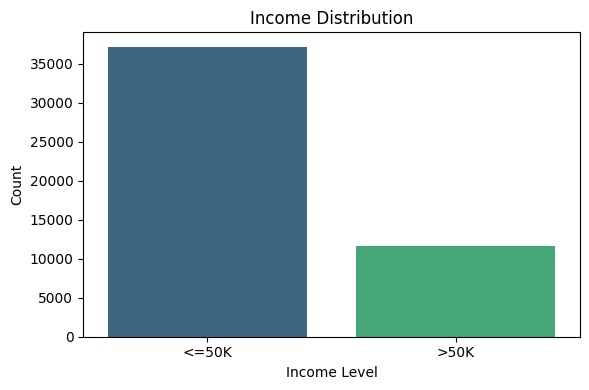

In [ ]:
# Income Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='income', palette='viridis')
plt.title("Income Distribution")
plt.xlabel("Income Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

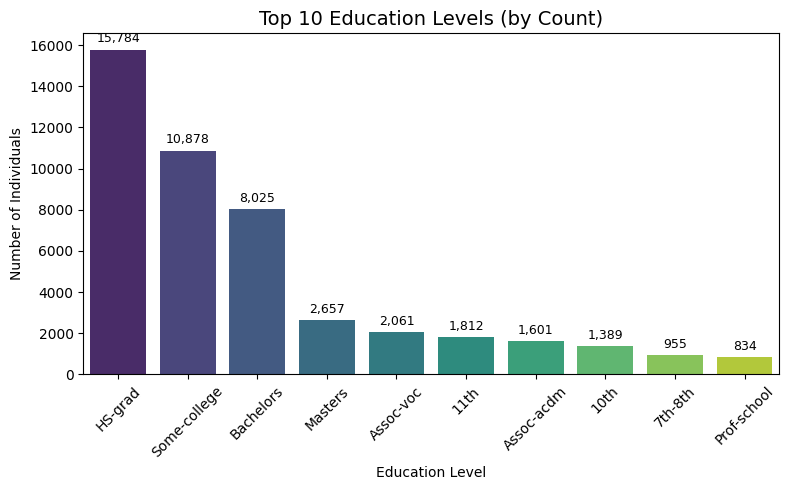

In [ ]:
# Top 10 education levels by count
top_edu = df['education'].value_counts().nlargest(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_edu.index, y=top_edu.values, palette='viridis')

# Adding value labels
for i, val in enumerate(top_edu.values):
    plt.text(i, val + 200, f'{val:,}', ha='center', va='bottom', fontsize=9)

# Labels and title
plt.title("Top 10 Education Levels (by Count)", fontsize=14)
plt.xlabel("Education Level")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The most common education level is HS-grad, followed by Some-college and Bachelors.

These top levels dominate the dataset and reflect the general education attainment of the population.

Educational attainment is known to strongly influence income levels, which will be explored in deeper modeling.

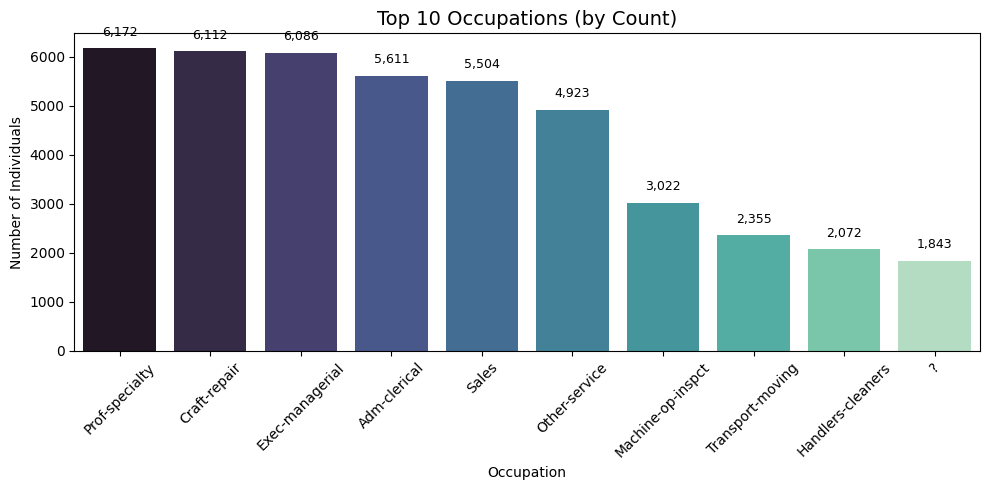

In [ ]:
# Top 10 occupations by count
top_occup = df['occupation'].value_counts().nlargest(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_occup.index, y=top_occup.values, palette='mako')

# Adding value labels
for i, val in enumerate(top_occup.values):
    plt.text(i, val + 200, f'{val:,}', ha='center', va='bottom', fontsize=9)

# Labels and title
plt.title("Top 10 Occupations (by Count)", fontsize=14)
plt.xlabel("Occupation")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The most frequent occupations include Prof-specialty, Craft-repair, and Exec-managerial.

These roles likely vary significantly in income levels.

The distribution highlights a diverse workforce, with a strong representation in both skilled labor and white-collar jobs.



In [ ]:
# Education Counts
edu_num_range = (df['education-num'].min(), df['education-num'].max())
print("Education-num ranges from:", edu_num_range)

Education-num ranges from: (1, 16)


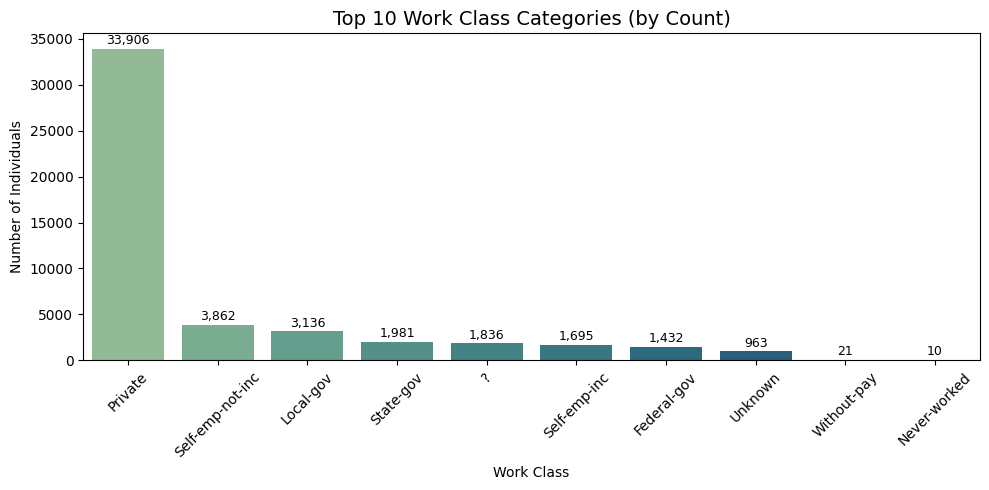

In [ ]:
# Top 10 workclass categories by count
top_workclass = df['workclass'].value_counts().nlargest(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_workclass.index, y=top_workclass.values, palette='crest')

# Adding value labels
for i, val in enumerate(top_workclass.values):
    plt.text(i, val + 200, f'{val:,}', ha='center', va='bottom', fontsize=9)

# Labels and title
plt.title("Top 10 Work Class Categories (by Count)", fontsize=14)
plt.xlabel("Work Class")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The majority of individuals are employed in the Private sector, followed by Self-employed and Government workers.

This confirms that most income earners fall under traditional employment settings, which may influence income consistency and benefits.

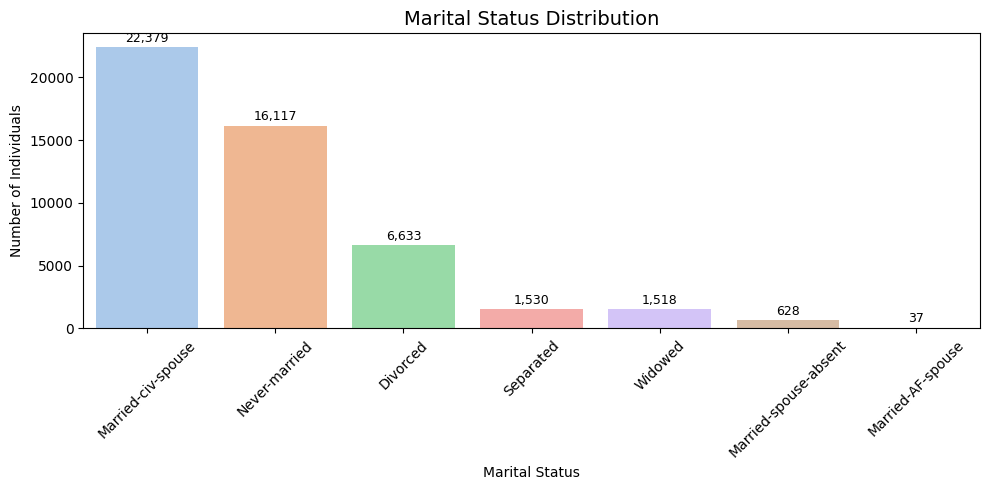

In [ ]:
# Marital status count
marital_counts = df['marital-status'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=marital_counts.index, y=marital_counts.values, palette='pastel')

# Adding value labels
for i, val in enumerate(marital_counts.values):
    plt.text(i, val + 200, f'{val:,}', ha='center', va='bottom', fontsize=9)

# Titles and labels
plt.title("Marital Status Distribution", fontsize=14)
plt.xlabel("Marital Status")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Most individuals are either Married-civ-spouse or Never-married.

Marital status can correlate with household income and stability.

These insights also align with common socioeconomic patterns.



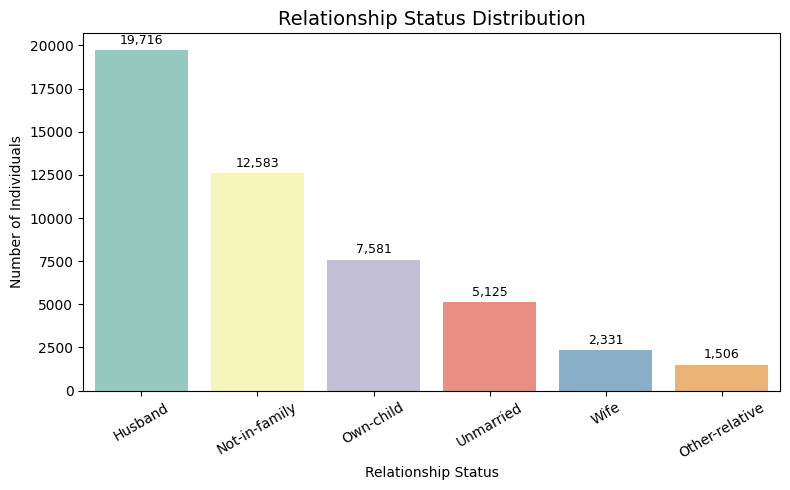

In [ ]:
# Relationship status count
relationship_counts = df['relationship'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=relationship_counts.index, y=relationship_counts.values, palette='Set3')

# Adding value labels
for i, val in enumerate(relationship_counts.values):
    plt.text(i, val + 200, f'{val:,}', ha='center', va='bottom', fontsize=9)

# Titles and axis
plt.title("Relationship Status Distribution", fontsize=14)
plt.xlabel("Relationship Status")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Top categories are Husband, Not-in-family, and Own-child.

Gender-related patterns are evident, such as "Husband" being highly correlated with "Male".

Relationship status interacts closely with marital-status and sex.

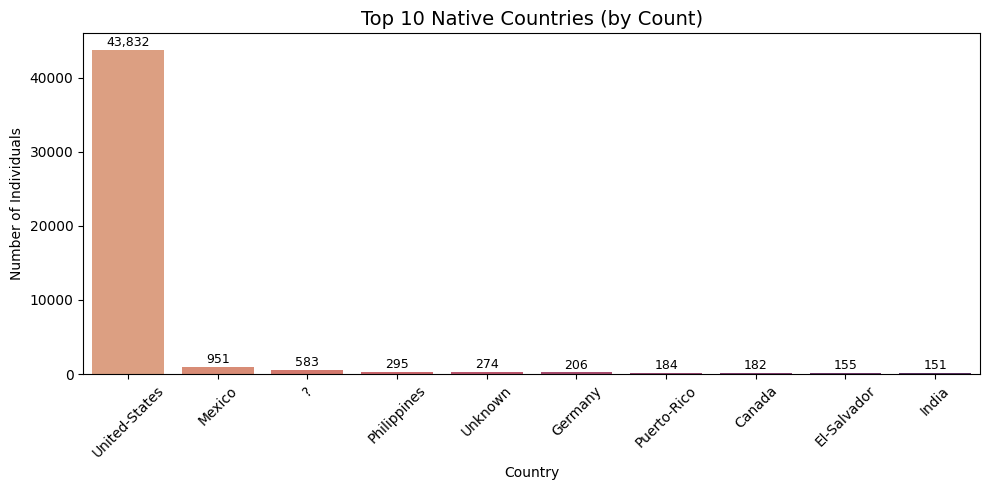

In [ ]:
# Top 10 native countries
top_countries = df['native-country'].value_counts().nlargest(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.index, y=top_countries.values, palette='flare')

# Adding value labels
for i, val in enumerate(top_countries.values):
    plt.text(i, val + 100, f'{val:,}', ha='center', va='bottom', fontsize=9)

# Titles and axis
plt.title("Top 10 Native Countries (by Count)", fontsize=14)
plt.xlabel("Country")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Overwhelming majority of individuals are from the United States.

Other countries like Mexico, Philippines, Germany, and Canada appear but are much smaller in number.

The skew toward the U.S. means models may generalize well for U.S.-based predictions but less so internationally.

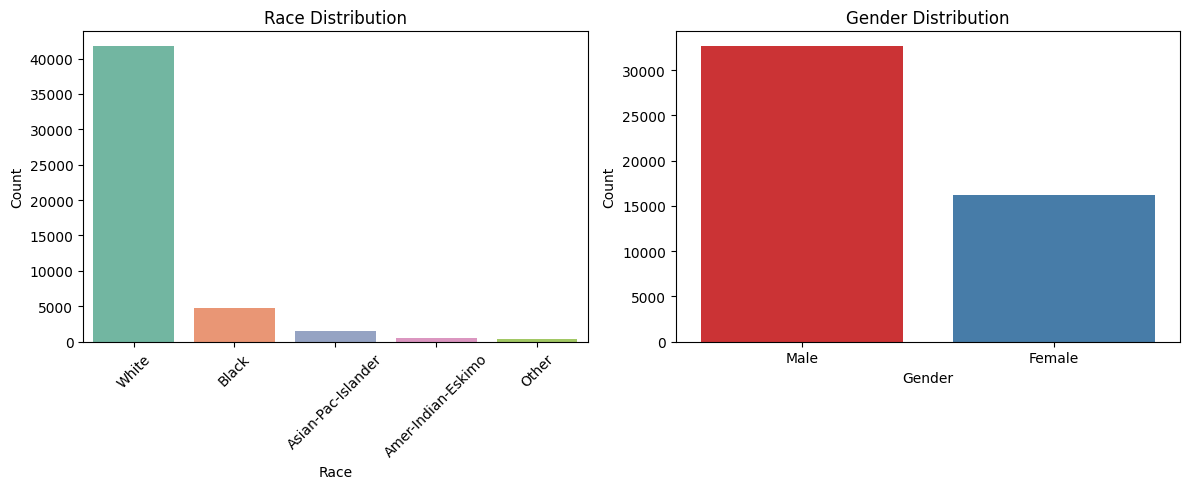

In [ ]:
# Setting figure layout
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Racing count plot
sns.countplot(data=df, x='race', ax=axes[0], palette='Set2')
axes[0].set_title('Race Distribution')
axes[0].set_xlabel('Race')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Gender count plot
sns.countplot(data=df, x='sex', ax=axes[1], palette='Set1')
axes[1].set_title('Gender Distribution')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')

# Adjust layout
plt.tight_layout()
plt.show()

The dataset is dominated by the White racial group.

Other groups such as Black, Asian-Pac-Islander, and Amer-Indian-Eskimo are present but with smaller representation.

The imbalance may influence model fairness and necessitates attention during bias assessment.



There are more males than females in the dataset.

This imbalance could affect how the model interprets the influence of gender on income.

Prior analysis already suggests a possible gender-income disparity.



####Grouped Bar Plot: Education vs Income

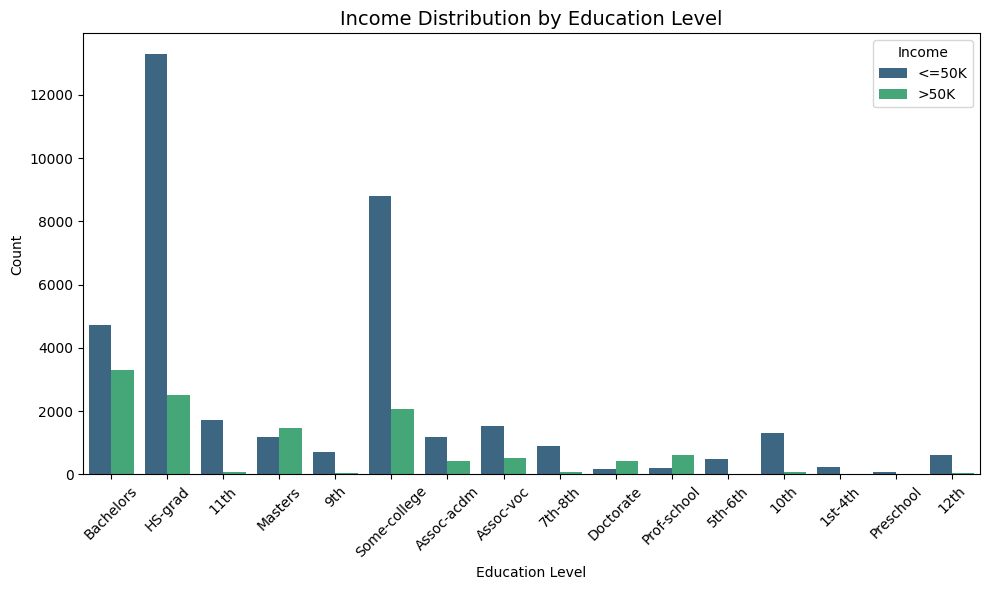

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='education', hue='income', palette='viridis')
plt.title("Income Distribution by Education Level", fontsize=14)
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Income")
plt.tight_layout()
plt.show()

Individuals with Bachelors, HS-grad, and Some-college show a notable presence in the >50K income group, indicating that mid-to-higher education levels do contribute to better earning potential.

However, the majority of individuals with HS-grad, Some-college, and even Bachelors degrees still fall into the <=50K category.

This means that while education is positively associated with higher income, most people even with moderate education are still in lower income brackets.

This suggests that while HS-grad is the most frequent education level among high earners, a large portion of HS-grads still earn ≤$50K.

Overall, there is a positive relationship between education and income, but it's nonlinear and influenced by other variables such as occupation, work hours, and capital gain.



Therefore, educational attainment alone is not a guaranteed predictor of income, but it does improve one's chances of earning more.

####Grouped Bar Plot: Occupation vs Income

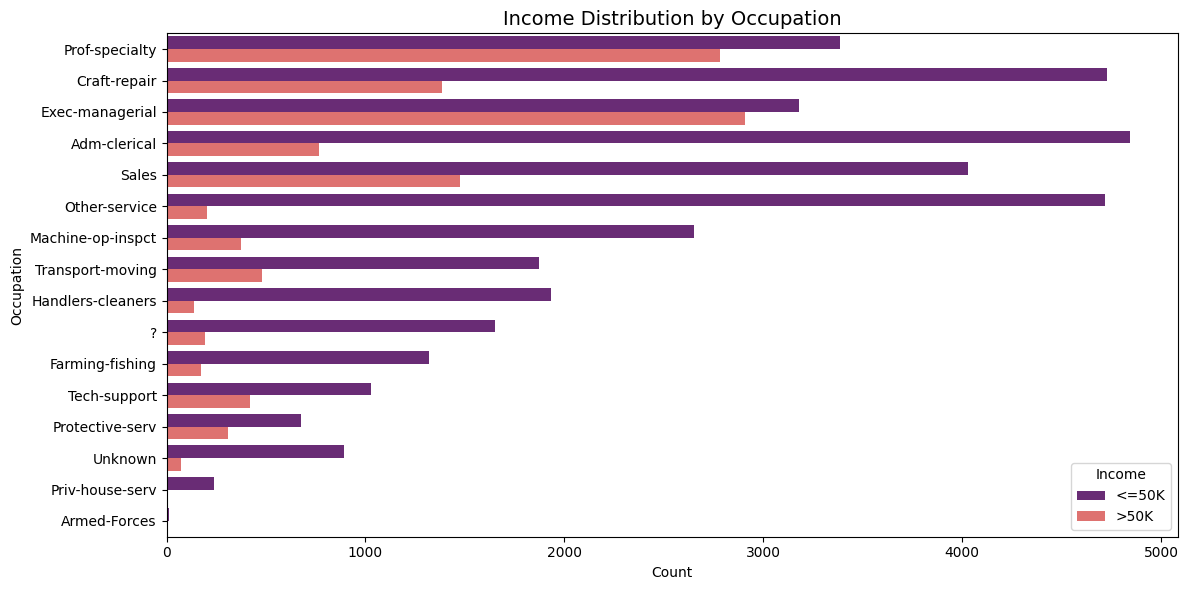

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='occupation', hue='income', palette='magma', order=df['occupation'].value_counts().index)
plt.title("Income Distribution by Occupation", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Occupation")
plt.legend(title="Income")
plt.tight_layout()
plt.show()

Exec-managerial, Prof-specialty, and Sales roles are more likely to yield >50K incomes.

Occupations such as Adm-clerical, Craft-repair, and Other-service are dominated by <=50K earners.

This suggests occupational type is a strong predictor of income.



####Grouped Bar Plot: Workclass vs Income

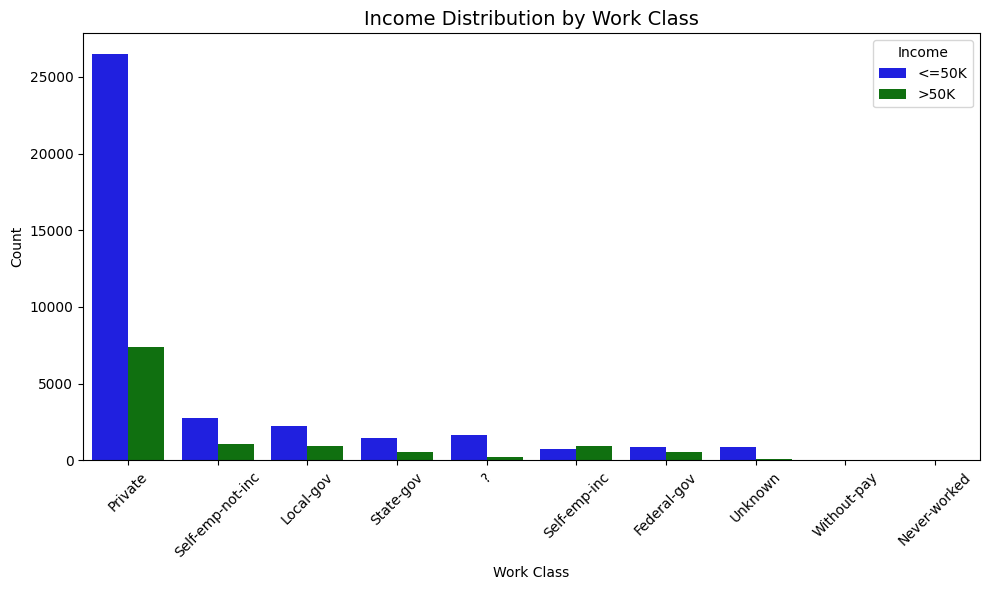

In [ ]:
# Defining custom color mapping for income categories
palette = {'<=50K': 'blue', '>50K': 'green'}


plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='workclass', hue='income', palette= palette, order=df['workclass'].value_counts().index)
plt.title("Income Distribution by Work Class", fontsize=14)
plt.xlabel("Work Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Income")
plt.tight_layout()
plt.show()

The Private sector dominates the dataset and accounts for the largest number of individuals in both income brackets.

However, within the Private sector, the majority of workers earn <=50K, while a substantial number also earn >50K.

This means that although high income is achievable in the Private sector, lower income levels are more prevalent.


####Grouped Bar Plot: Marital Status vs Income

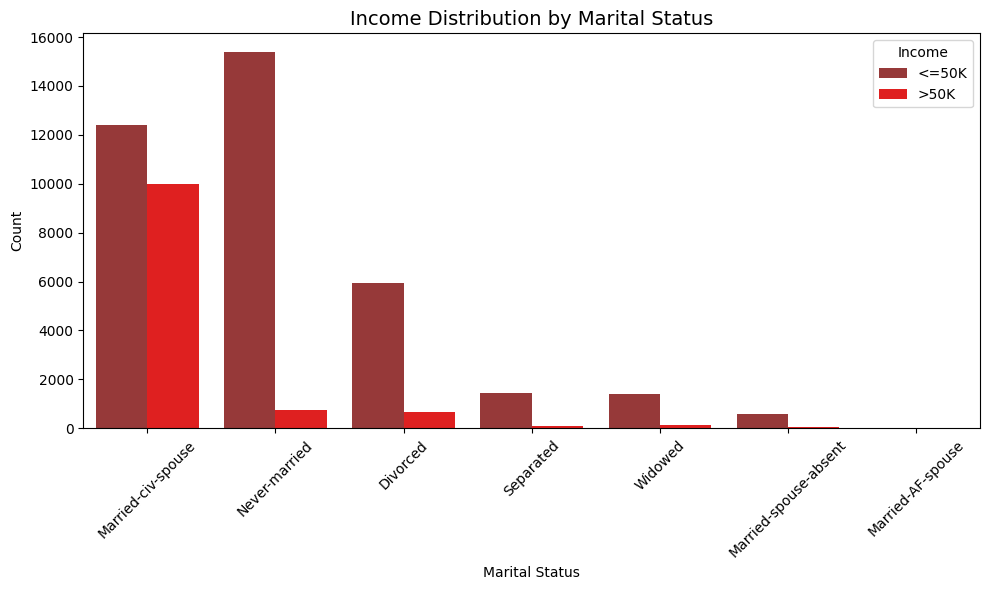

In [ ]:
# Defining custom color mapping for income categories
palette = {'<=50K': 'brown', '>50K': 'red'}

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='marital-status', hue='income', palette=palette, order=df['marital-status'].value_counts().index)
plt.title("Income Distribution by Marital Status", fontsize=14)
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Income")
plt.tight_layout()
plt.show()

Individuals who are Married-civ-spouse are more likely to earn >50K than other marital groups.

However, Married-civ-spouse, Never-married, and Divorced individuals also make up the majority of those earning <=50K, indicating these categories are the most common in the dataset.

This suggests that while marital stability (e.g., Married-civ-spouse) may increase the likelihood of higher income  potentially due to dual-income households or financial stability, it does not guarantee it.

Overall, marital status is a relevant factor in income, but its impact is influenced by other variables such as education, workclass, and hours worked.

####Grouped Bar Plot: Relationship vs Income

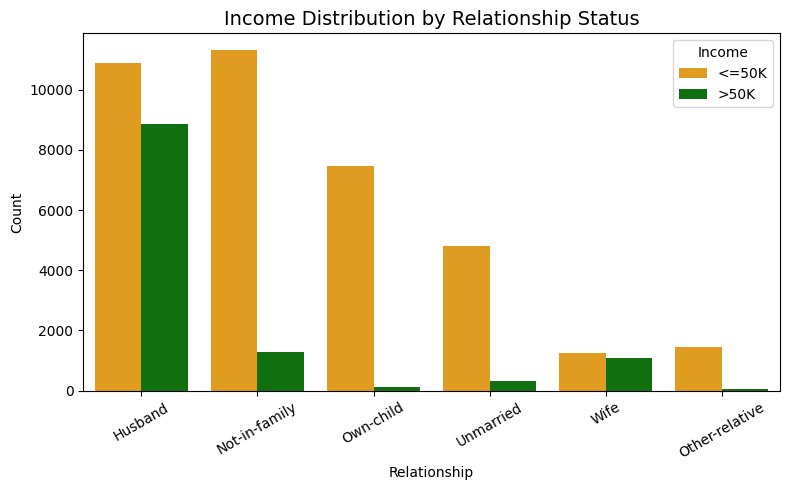

In [ ]:
# Defining custom color mapping for income categories
palette = {'<=50K': 'orange', '>50K': 'green'}


plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='relationship', hue='income', palette=palette, order=df['relationship'].value_counts().index)
plt.title("Income Distribution by Relationship Status", fontsize=14)
plt.xlabel("Relationship")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.legend(title="Income")
plt.tight_layout()
plt.show()

Husbands appear significantly in both income groups, but they are more prominent among those earning >50K compared to other relationship types.

However, a large number of husbands also earn <=50K, reflecting their overall high representation in the dataset.

Categories like Not-in-family, Unmarried, and Own-child are dominated by individuals in the <=50K income bracket.

This suggests that while being a household head (e.g., husband) is associated with higher income likelihood, it is not a guarantee, and family structure interacts with other factors like occupation and education.

The relationship variable highlights socioeconomic patterns, where income is linked to both role in the household and personal demographics.

 Grouped Bar Plot: Native Country vs Income (Top 10 Only)

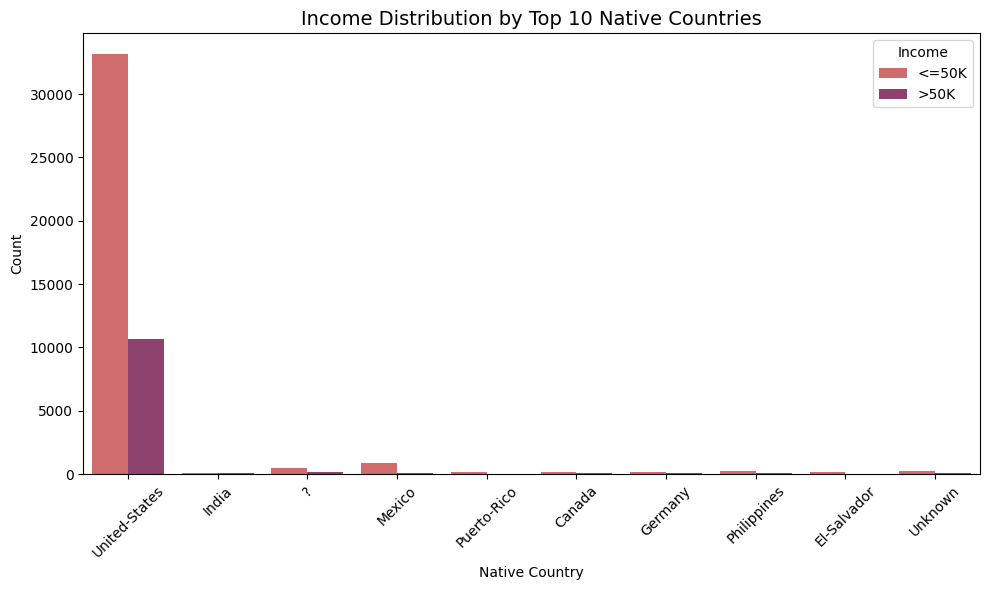

In [ ]:
top_countries = df['native-country'].value_counts().nlargest(10).index
plt.figure(figsize=(10, 6))
sns.countplot(data=df[df['native-country'].isin(top_countries)],
              x='native-country', hue='income', palette='flare')
plt.title("Income Distribution by Top 10 Native Countries", fontsize=14)
plt.xlabel("Native Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Income")
plt.tight_layout()
plt.show()

The United States dominates the dataset, with a relatively balanced distribution of income across both <=50K and >50K groups.

Immigrant groups from countries like Mexico, Philippines, and India show much lower proportions of individuals earning >50K.

This difference may be influenced by factors such as education levels, type of employment, and access to high-paying job markets.

However, it's also important to note that the dataset contains far fewer individuals from non-U.S. countries, which could skew the interpretation.

As a result, country of origin appears to be a moderate socio-economic factor, but its impact should be interpreted cautiously due to sample size imbalances.

In [ ]:
# Work Hours and Capital Stats
print("\nHours-per-week statistics:\n", df['hours-per-week'].describe())
print("\nCapital-gain statistics:\n", df['capital-gain'].describe())
print("\nCapital-loss statistics:\n", df['capital-loss'].describe())


Hours-per-week statistics:
 count    48842.000000
mean        40.422382
std         12.391444
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64

Capital-gain statistics:
 count    48842.000000
mean      1079.067626
std       7452.019058
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64

Capital-loss statistics:
 count    48842.000000
mean        87.502314
std        403.004552
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital-loss, dtype: float64


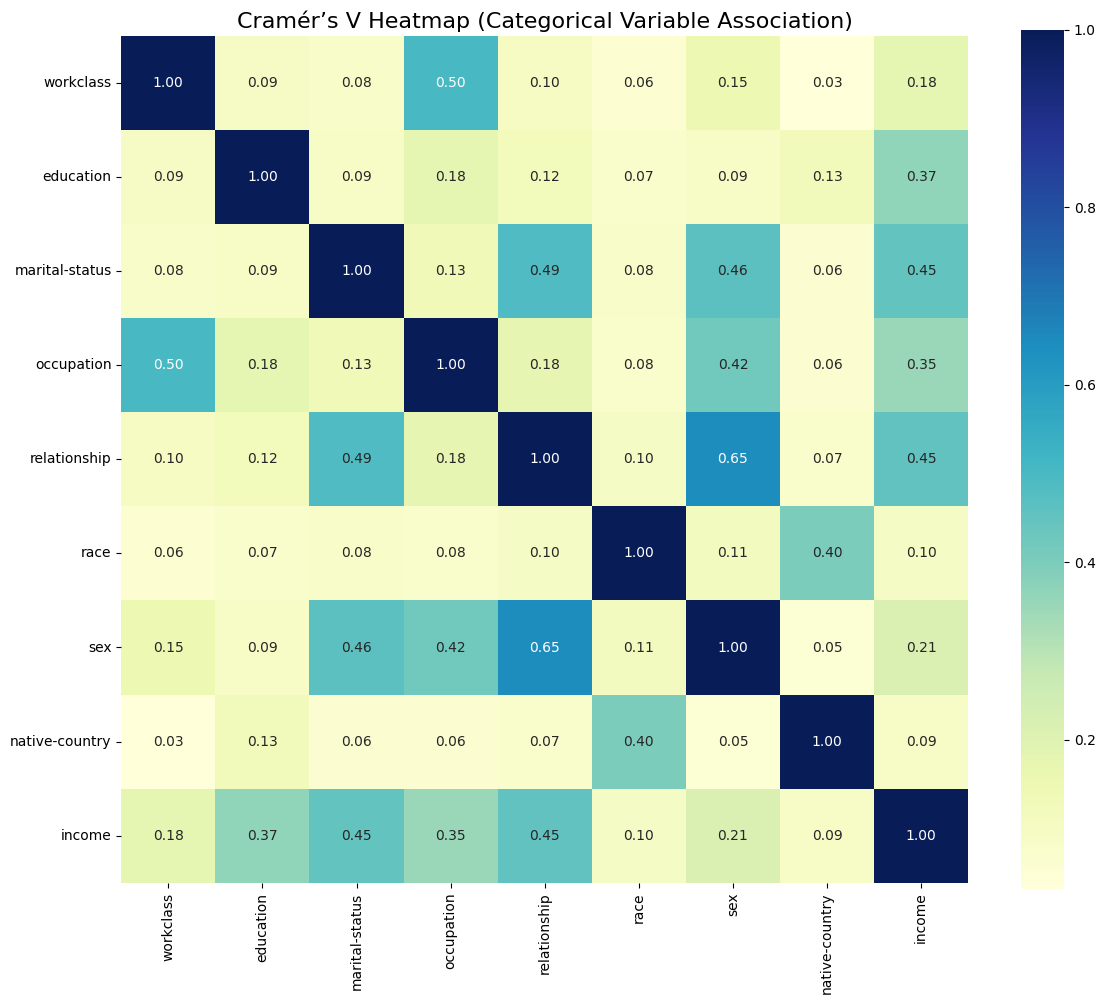

In [ ]:
# Function to compute Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2_corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    r_corr = r - ((r-1)**2)/(n-1)
    k_corr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2_corr / min((k_corr-1), (r_corr-1)))

# Applying to all categorical columns
cat_cols = df.select_dtypes(include='object').columns
cramer_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)

for col1 in cat_cols:
    for col2 in cat_cols:
        cramer_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

cramer_matrix = cramer_matrix.astype(float)

# Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(cramer_matrix, annot=True, cmap="YlGnBu", square=True, fmt=".2f")
plt.title("Cramér’s V Heatmap (Categorical Variable Association)", fontsize=16)
plt.tight_layout()
plt.show()

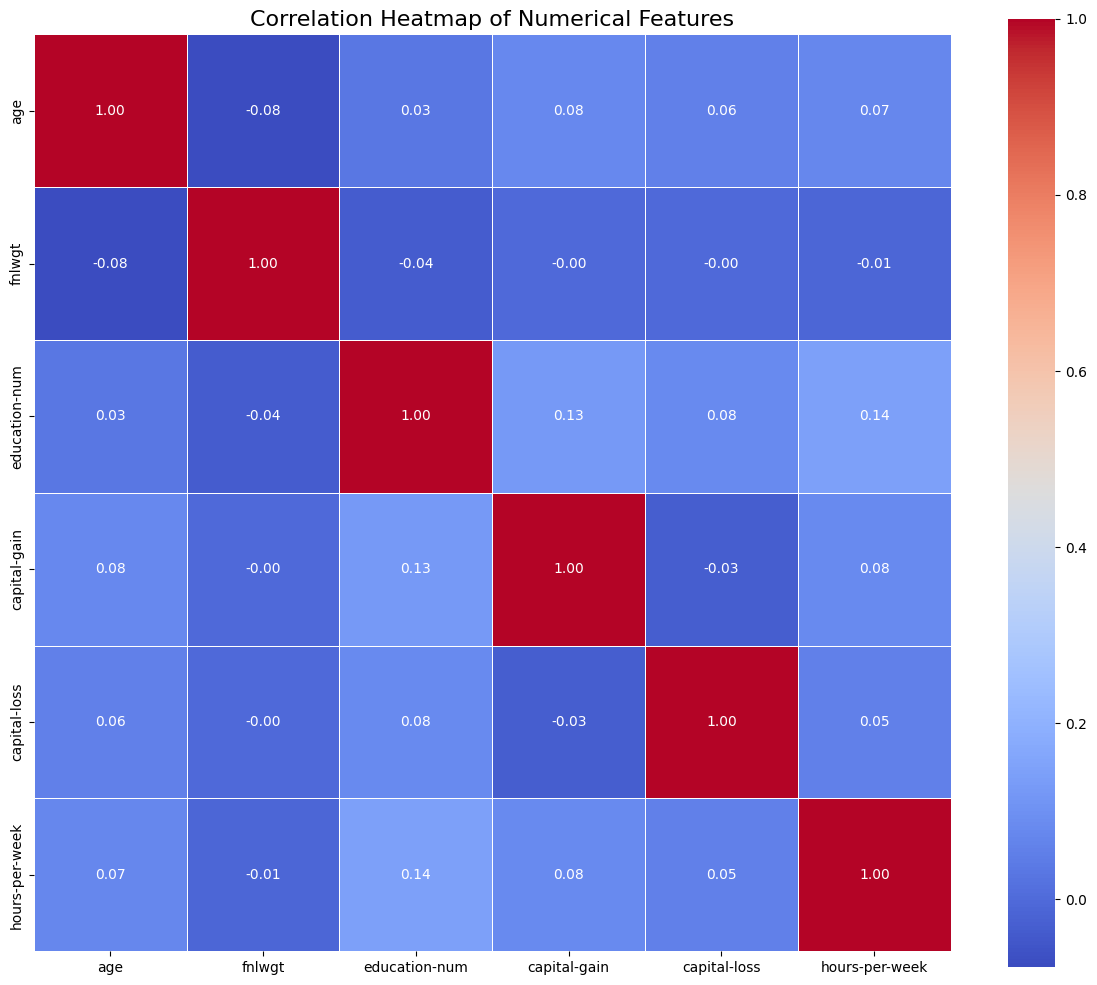

In [ ]:
# Selecting numerical features
num_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr = num_df.corr()

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

 General Observations
Several features (e.g., relationship and sex) are highly correlated (correlation ≈ 0.65), indicating redundancy.

Features like education, workclass, and occupation will be crucial in building a reliable income prediction model.

Some categorical variables (e.g., native-country) are highly imbalanced and may need aggregation or simplification.

In [ ]:
# Cramér's V between each categorical feature and income
target_cramers = {col: cramers_v(df[col], df['income']) for col in cat_cols}
pd.Series(target_cramers).sort_values(ascending=False)

,0
income,0.999944
relationship,0.454379
marital-status,0.448170
education,0.365452
occupation,0.349640
sex,0.214532
workclass,0.181239
race,0.099447
native-country,0.091692


Top 3 predictors of income (among categorical variables):
relationship, marital-status, education

Variables like race and native-country have minimal standalone influence, but may interact with other factors (e.g., education, workclass).

Relationship	0.454	Strongest actual correlation. Indicates that family role (e.g., husband, not-in-family) strongly predicts income level.

Marital-status	0.448	Very closely tied to income. Married individuals, especially Married-civ-spouse, tend to earn more.

Education	0.365	Moderate-to-strong correlation. Higher education is associated with higher income, though not determinative alone.

Sex	0.215	Weak-to-moderate correlation. Male respondents more often fall into >50K income, but not overwhelmingly so.

Workclass	0.174	Weak correlation. Sector of employment matters, but less so than relationship or occupation.

Race	0.099	Very weak correlation. Indicates minor impact on income prediction in this dataset.

Native-country	0.092	Very weak correlation. Suggests that while there are disparities, country of origin isn’t a strong standalone predictor in this sample.


###Preprocessing & Feature Engineering

In [ ]:
#  Dropping irrelevant or redundant columns
df.drop(['fnlwgt'], axis=1, inplace=True)

In [ ]:
#  Encoding the target variable
df['income'] = df['income'].astype(str).str.strip().map({'<=50K': 0, '>50K': 1})

#  Ordinal encoding education into education_level
education_order = [
    'Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th',
    '11th', '12th', 'HS-grad', 'Some-college',
    'Assoc-voc', 'Assoc-acdm', 'Bachelors',
    'Masters', 'Prof-school', 'Doctorate'
]
edu_mapping = {level: idx for idx, level in enumerate(education_order)}
df['education_level'] = df['education'].map(edu_mapping)

if 'education' in df.columns:  # drop string-based education if still there
    df.drop('education', axis=1, inplace=True)

# Feature engineering
df['log_capital_gain'] = np.log1p(df['capital-gain'])
df['age_hours_interaction'] = df['age'] * df['hours-per-week']

# One-hot encoding nominal categorical variables
df = pd.get_dummies(df, columns=[
    'workclass', 'marital-status', 'occupation',
    'relationship', 'race', 'sex', 'native-country'
], drop_first=True)

# Defining features and target
X = df.drop('income', axis=1)
y = df['income']

# Scaling numeric features
numeric_cols = ['age', 'education-num', 'capital-gain', 'capital-loss',
                'hours-per-week', 'education_level', 'log_capital_gain', 'age_hours_interaction']
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

###Model Development

In [ ]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Training Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predicting
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

Accuracy: 0.8529020370559934

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.93      0.91      7431
           1       0.72      0.62      0.67      2338

    accuracy                           0.85      9769
   macro avg       0.81      0.77      0.79      9769
weighted avg       0.85      0.85      0.85      9769

Confusion Matrix:
 [[6878  553]
 [ 884 1454]]
ROC AUC Score: 0.8973590393467636


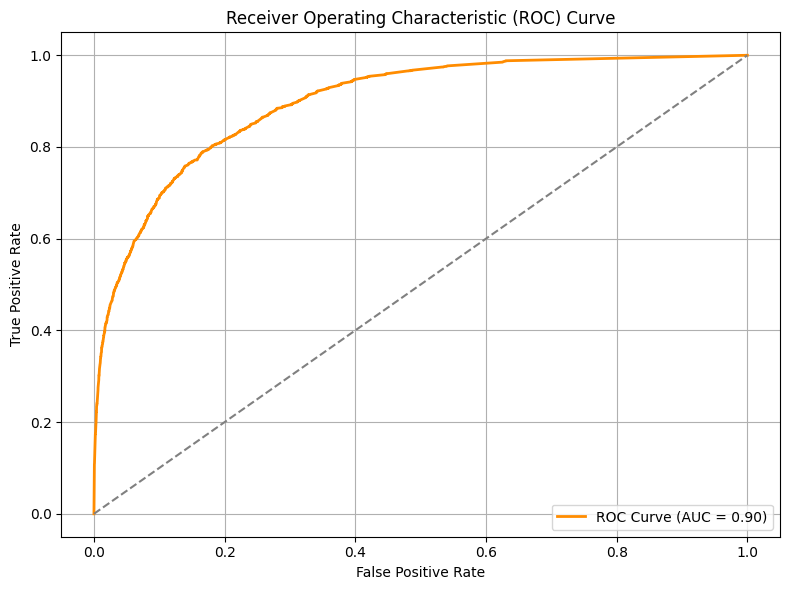

In [ ]:
# # Evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

# Plotting ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

Logistic Regression Accuracy: 0.8539256832838571

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.91      7431
           1       0.74      0.60      0.66      2338

    accuracy                           0.85      9769
   macro avg       0.81      0.77      0.79      9769
weighted avg       0.85      0.85      0.85      9769

Confusion Matrix:
 [[6928  503]
 [ 924 1414]]
ROC AUC Score: 0.9087093705777209


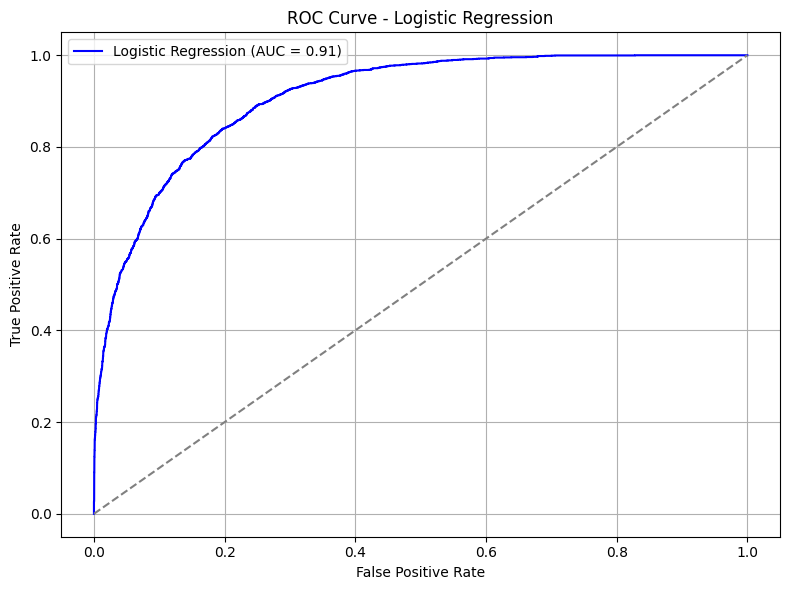

In [ ]:
# Initialize and training the model
log_reg = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
log_reg.fit(X_train, y_train)

# Predicting class labels and probabilities
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

# Evaluating performance
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_lr))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr)
auc_score = roc_auc_score(y_test, y_proba_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.2f})", color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

XGBoost Accuracy: 0.8762411710512846

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92      7431
           1       0.78      0.67      0.72      2338

    accuracy                           0.88      9769
   macro avg       0.84      0.80      0.82      9769
weighted avg       0.87      0.88      0.87      9769

Confusion Matrix:
 [[7000  431]
 [ 778 1560]]
ROC AUC Score: 0.9308973609387718


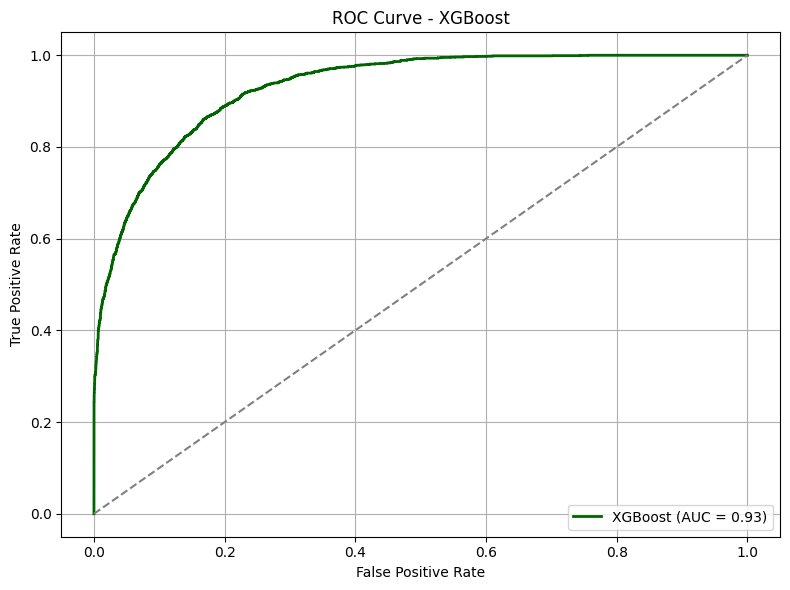

In [ ]:
# Initializing and training the model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Predicting class labels and probabilities
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_xgb))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)
auc_score = roc_auc_score(y_test, y_proba_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkgreen', lw=2, label=f"XGBoost (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019826 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 882
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 79
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239270 -> initscore=-1.156685
[LightGBM] [Info] Start training from score -1.156685
LightGBM Accuracy: 0.8747057017094892
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92      7431
           1       0.79      0.66      0.71      2338

    accuracy                           0.87      9769
   macro avg       0.84      0.80      0.82      9769
weighted avg       0.87      0.87      0.87      9769

Confusion Matrix:
 [[7013  418]
 [ 806 1532]]
ROC AUC S

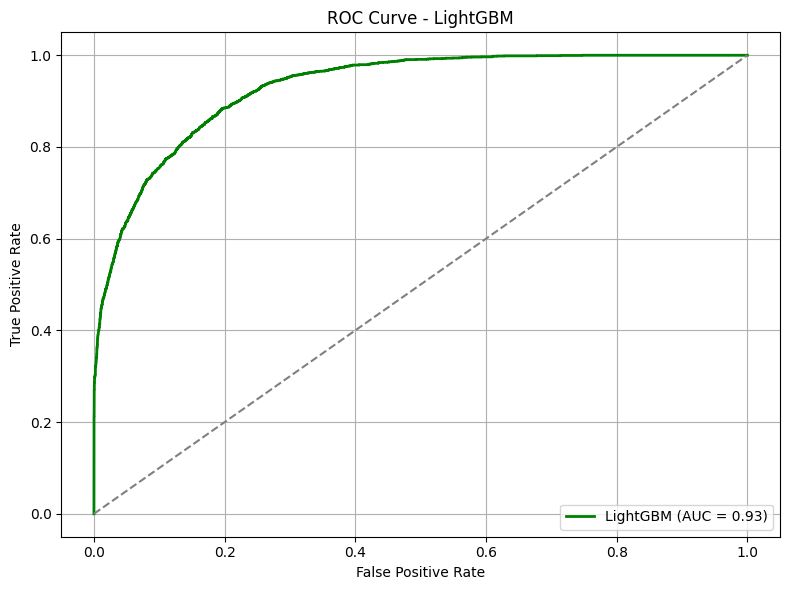

In [ ]:
# Initializing the LightGBM model
lgb_model = lgb.LGBMClassifier(random_state=42)

# Training the model
lgb_model.fit(X_train, y_train)

# Making predictions
y_pred_lgb = lgb_model.predict(X_test)
y_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

# Evaluating performance
print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgb))
print("Classification Report:\n", classification_report(y_test, y_pred_lgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lgb))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_lgb))

# Plotting ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_lgb)
auc_score = roc_auc_score(y_test, y_proba_lgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'LightGBM (AUC = {auc_score:.2f})', color='green', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve - LightGBM')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

CatBoost Accuracy: 0.8776742757702938

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92      7431
           1       0.79      0.66      0.72      2338

    accuracy                           0.88      9769
   macro avg       0.85      0.80      0.82      9769
weighted avg       0.87      0.88      0.87      9769

Confusion Matrix:
 [[7020  411]
 [ 784 1554]]
ROC AUC Score: 0.9309604448752877


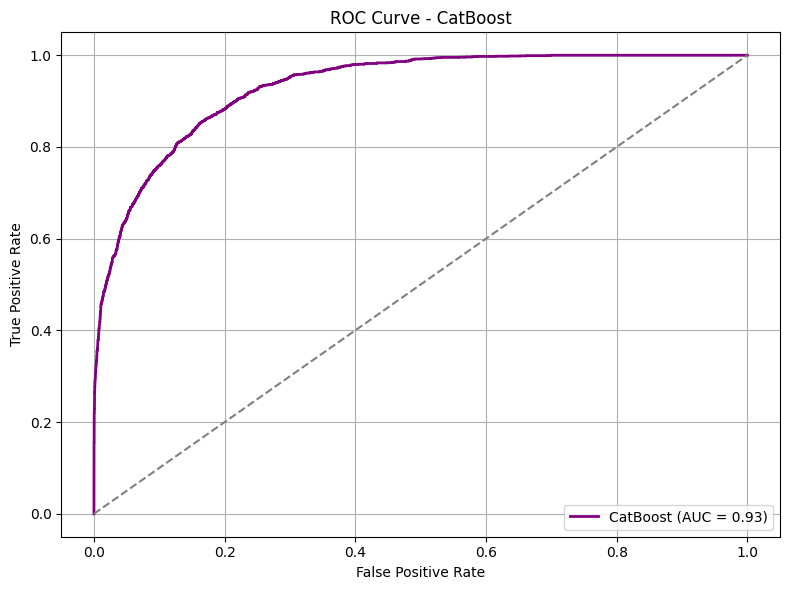

In [ ]:
# Initializing the model
cat_model = CatBoostClassifier(verbose=0, random_state=42)

# Training the model
cat_model.fit(X_train, y_train)

# Predicting
y_pred_cat = cat_model.predict(X_test)
y_proba_cat = cat_model.predict_proba(X_test)[:, 1]

# Evaluating performance
print("CatBoost Accuracy:", accuracy_score(y_test, y_pred_cat))
print("\nClassification Report:\n", classification_report(y_test, y_pred_cat))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_cat))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_cat))

# Plotting ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_cat)
auc_score = roc_auc_score(y_test, y_proba_cat)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'CatBoost (AUC = {auc_score:.2f})', color='purple', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve - CatBoost')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

SVM Accuracy: 0.8603746545193981

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.91      7431
           1       0.77      0.59      0.67      2338

    accuracy                           0.86      9769
   macro avg       0.83      0.77      0.79      9769
weighted avg       0.85      0.86      0.85      9769

Confusion Matrix:
 [[7027  404]
 [ 960 1378]]
ROC AUC Score: 0.8955869620698624


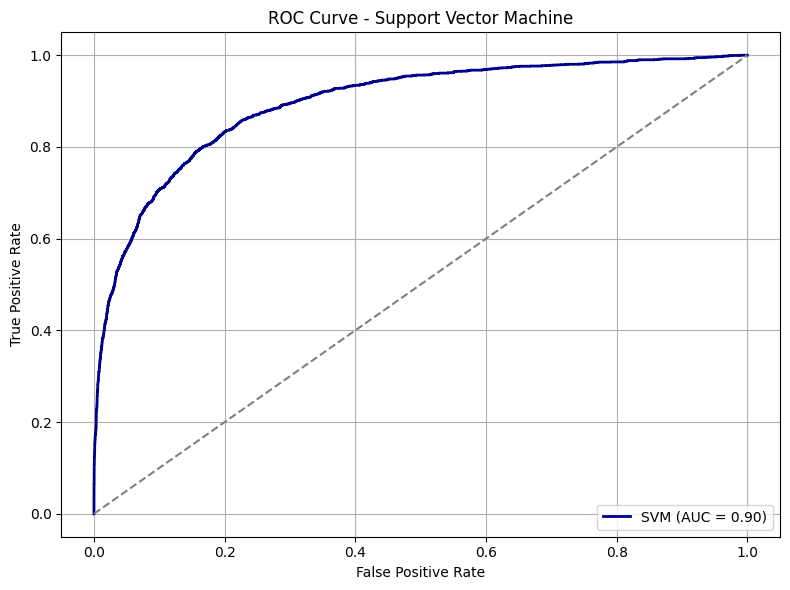

In [ ]:
# Initializing the SVM model with probability enabled
svm_model = SVC(kernel='rbf', probability=True, random_state=42)

# Training the model
svm_model.fit(X_train, y_train)

# Predicting
y_pred_svm = svm_model.predict(X_test)
y_proba_svm = svm_model.predict_proba(X_test)[:, 1]

# Evaluation
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_svm))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_svm)
auc_score = roc_auc_score(y_test, y_proba_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'SVM (AUC = {auc_score:.2f})', color='darkblue', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve - Support Vector Machine')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

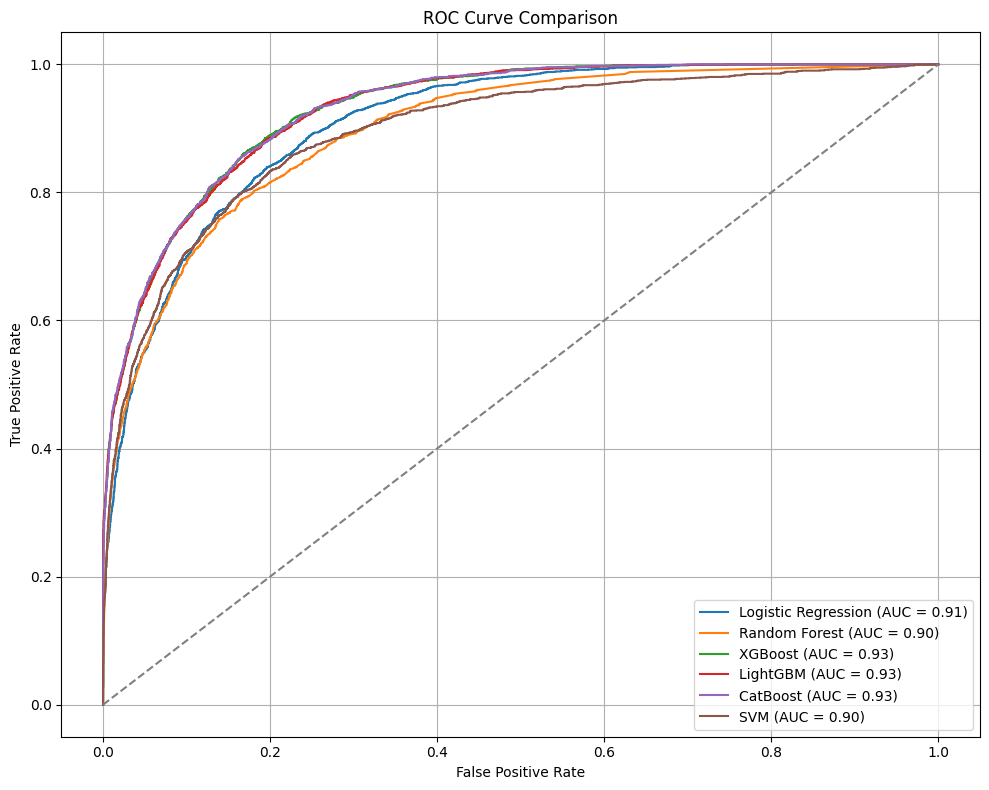

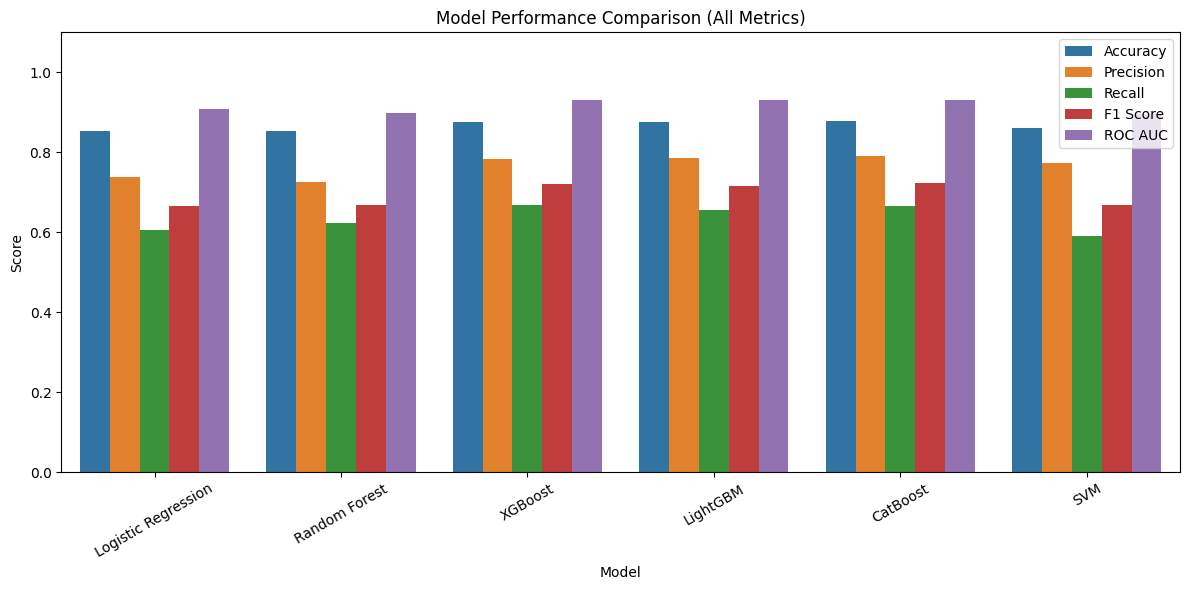

Model Metrics Summary Table:

                 Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
4             CatBoost    0.8777     0.7908  0.6647    0.7223   0.9310
2              XGBoost    0.8762     0.7835  0.6672    0.7207   0.9309
3             LightGBM    0.8747     0.7856  0.6553    0.7146   0.9299
0  Logistic Regression    0.8539     0.7376  0.6048    0.6646   0.9087
1        Random Forest    0.8529     0.7245  0.6219    0.6693   0.8974
5                  SVM    0.8604     0.7733  0.5894    0.6689   0.8956


In [ ]:
# Trained models and  predictions
models = {
    "Logistic Regression": (log_reg, y_pred_lr, y_proba_lr),
    "Random Forest": (rf_model, y_pred, y_proba),
    "XGBoost": (xgb_model, y_pred_xgb, y_proba_xgb),
    "LightGBM": (lgb_model, y_pred_lgb, y_proba_lgb),
    "CatBoost": (cat_model, y_pred_cat, y_proba_cat),
    "SVM": (svm_model, y_pred_svm, y_proba_svm)
}

# Collecting metrics
results = []
plt.figure(figsize=(10, 8))
for name, (model, y_pred, y_proba) in models.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC AUC": auc
    })

    # Ploting ROC Curve
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

# Diagonal no-skill line
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Bar Chart: Comparing all metrics
results_df = pd.DataFrame(results)
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric')
plt.title("Model Performance Comparison (All Metrics)")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=30)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Printing Summary Table
print("Model Metrics Summary Table:\n")
print(results_df.sort_values(by="ROC AUC", ascending=False).round(4))

###Feature Importance

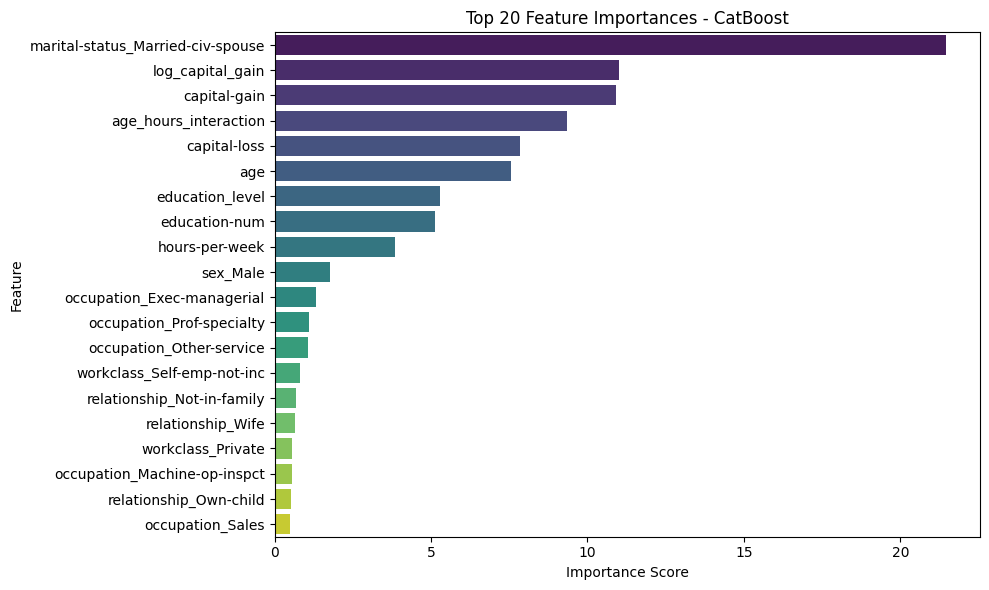

In [ ]:
# Using CatBoost
model = cat_model  # or xgb_model, rf_model, lgb_model
model_name = "CatBoost"  # update accordingly

# Extracting feature importances and match with feature names
feature_importances = model.feature_importances_
feature_names = X_train.columns

# Creating DataFrame
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False).head(20)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title(f"Top 20 Feature Importances - {model_name}")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

###Hyperparameter Tunning

In [ ]:
# Defining parameter grid
param_grid = {
    'iterations': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5]
}

# Initializing CatBoost (silent training)
catboost_model = CatBoostClassifier(verbose=0, random_state=42)

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=catboost_model,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

# Fitting search on training data
grid_search.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best ROC AUC Score:", grid_search.best_score_)

# Using best estimator to predict
best_cat_model = grid_search.best_estimator_
y_pred_best_cat = best_cat_model.predict(X_test)
y_proba_best_cat = best_cat_model.predict_proba(X_test)[:, 1]

Best Parameters: {'depth': 6, 'iterations': 200, 'l2_leaf_reg': 1, 'learning_rate': 0.1}
Best ROC AUC Score: 0.9276794399648036


In [ ]:
# Defining the parameter grid for LightGBM
param_grid = {
    'num_leaves': [31, 50, 70],
    'max_depth': [5, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200],
    'reg_lambda': [0, 1, 3]  # L2 regularization
}

# Initializing the LightGBM model
lgb_model = LGBMClassifier(random_state=42)

# GridSearchCV setup
grid_search_lgb = GridSearchCV(
    estimator=lgb_model,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fitting to training data
grid_search_lgb.fit(X_train, y_train)

# Best parameters and best score
print("Best Parameters:", grid_search_lgb.best_params_)
print("Best ROC AUC Score:", grid_search_lgb.best_score_)

# Using best estimator to predict
best_lgb_model = grid_search_lgb.best_estimator_
y_pred_best_lgb = best_lgb_model.predict(X_test)
y_proba_best_lgb = best_lgb_model.predict_proba(X_test)[:, 1]

Fitting 5 folds for each of 162 candidates, totalling 810 fits
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020172 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 882
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 79
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239270 -> initscore=-1.156685
[LightGBM] [Info] Start training from score -1.156685
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

In [ ]:
# Saving best-performing CatBoost model
cat_model.save_model("best_catboost_model.cbm", format="cbm")

In [ ]:
files.download("best_catboost_model.cbm")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###Key Insights From Modeling
CatBoost achieved the highest ROC AUC score (0.9310), indicating superior overall classification performance, especially in balancing sensitivity and specificity.

It also had the highest accuracy (87.77%), and performed best across precision and F1 score.

XGBoost followed closely behind, with nearly identical performance to CatBoost, making it a strong alternative.

LightGBM also performed competitively, with a slightly lower recall but still maintaining high precision and AUC.

Logistic Regression and Random Forest showed identical results and performed well but lagged behind in recall and F1.

SVM had slightly better precision than logistic regression but the lowest recall and ROC AUC of all models.

The tuned model achieved a slightly lower AUC (0.9277) than the original untuned CatBoost (0.9310), which means that the default configuration was already very strong.


###Recommendation

Deploying the original CatBoost model (without tuning) for best accuracy and robustness.
Continue monitoring post-deployment performance and fairness, and considering LightGBM/XGBoost as scalable alternatives.


###Conclusion

CatBoost is the best-performing model overall in this analysis, achieving the top score in ROC AUC, accuracy, and F1 score, making it the recommended choice for income level prediction in this dataset.


The capstone analysis demonstrates that income is multifactorial, influenced by a combination of:

Demographics (sex, marital status, relationship)

Socioeconomic roles (workclass, occupation)

Human capital (education, hours worked)

And to a lesser extent, country of origin and race

These findings provide a data-driven foundation for predicting income levels and understanding the structure of socioeconomic inequality.